In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_chemprop=True)
molecules = qm9.get_molecules()
df = qm9.load()

2026-04-15 16:02:52.349 | INFO     | src.datasets:load:493 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-15 16:02:52.587 | INFO     | src.datasets:_sample_qm9_df:685 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-15 16:02:52.588 | INFO     | src.datasets:_add_requested_descriptors:126 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-15 16:02:52.588 | INFO     | src.features:compute_chemprop_embeddings:276 - Computing Chemprop embeddings on mps...
2026-04-15 16:02:52.588 | WARNING  | src.features:compute_chemprop_embeddings:284 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-04-15 16:02:56.204 | INFO     | src.datasets:_add_requested_descriptors:149 - Added descriptor column(s): ['chemprop_embedding']
2026-04-15 16:03:21.056 | SUCCESS  | src.datasets:get_molecules:1168 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).
2026-

In [4]:
len(df['chemprop_embedding'].to_list()[0])

25

In [5]:
len(molecules[0:2])

2

In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="chemprop",
    dist_type="euclidean",
)

2026-04-15 16:06:54.513 | INFO     | src.distance:get_matrix:28 - Loading cached distance matrix from data/QM9/dist_chemprop_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:10<00:00,  1.02s/it]


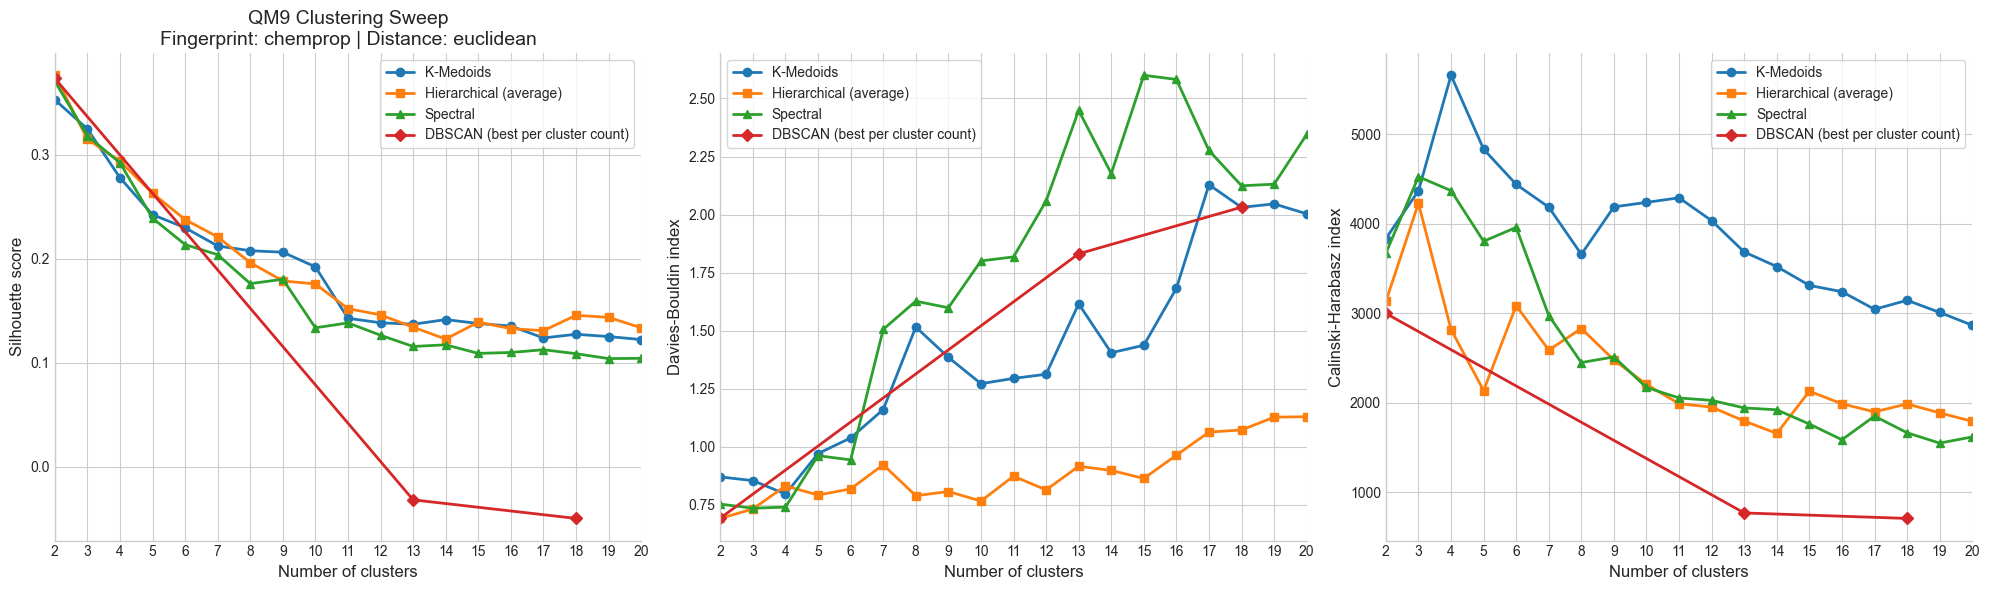

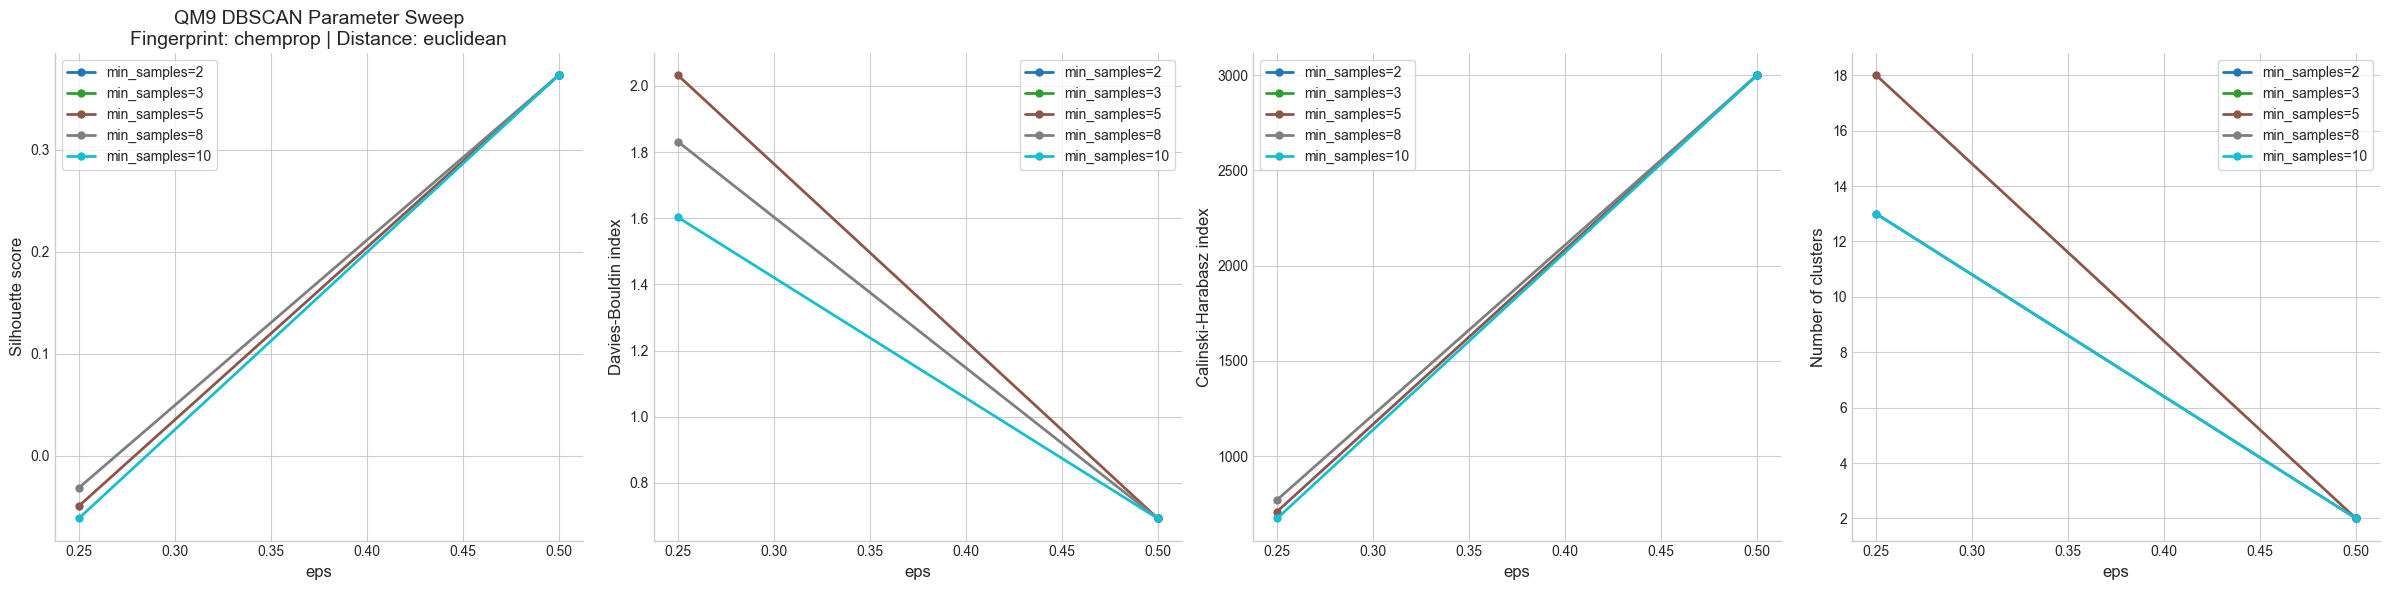

2026-04-15 16:08:09.398 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:840 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.png
2026-04-15 16:08:09.399 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:842 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/chemprop/dbscan_parameter_sweep.png
2026-04-15 16:08:09.399 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved clustering sweep results to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.json


In [8]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [9]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(4966), np.int64(4967)), (np.int64(953), np.int64(954)), (np.int64(4857), np.int64(4858)), (np.int64(4905), np.int64(4906)), (np.int64(579), np.int64(580)), (np.int64(933), np.int64(934)), (np.int64(4950), np.int64(4951)), (np.int64(1657), np.int64(1661)), (np.int64(1029), np.int64(1030)), (np.int64(998), np.int64(1000))]


In [9]:
print(mols[0])

(Atoms(symbols='N2HFC2HC2NC', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='CNHNCFCHC2N', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [10]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

In [10]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)

In [11]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [12]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-15 16:09:30.790 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png


{'coords': array([[ 10.14205116, -10.13382359],
        [ 13.46424475,  -0.7466578 ],
        [ -2.21504068, -11.08364866],
        ...,
        [  4.44548678,  -6.13645022],
        [-10.07667368,  -6.36316019],
        [  3.75542316,  -6.61688013]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'hierarchical'}

In [13]:
average_numeric_by_cluster(df, "labels_hier")

labels_hier,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,3177,2.007051,17.638338,122.567202,0.177211,41.700031,0.825327,12.891098,8.74221,1.047529,0.285175,2.005074,2.69531,0.080511,0.33109,0.588399,0.918477,2.253069,6.138181,0.520302,1.808939,3.672962,6.529745,35.779352,1.255042,0.004721,0.310041,0.05288,0.162732,0.181303,0.002518,0.051621,0.136292,0.43091,0.004721,2.740006,2.94181,74.729068,-6.572419,-0.05259,6.519805,1259.595005,3.930377,-11305.031173,-11304.791072,-11304.765401,-11305.957662,32.070941,-74.693335,-75.133038,-75.560673,-69.547587,3.593131,1.307194,1.016031,56.43689,27.132515,16.430595
1,1705,2.204174,18.758944,123.320235,-0.009971,29.07566,0.908467,12.796716,8.858065,2.548974,0.0,2.144953,1.676246,0.038886,0.073959,0.887155,0.906745,1.678006,7.087977,0.271554,0.503812,6.070968,6.077419,41.421701,1.274415,0.0,0.395308,0.0,0.077419,0.032845,0.000587,0.019355,0.103812,0.693842,0.0,2.01173,2.304219,76.003472,-6.497851,0.866336,7.364248,1085.405889,4.292777,-10996.152566,-10995.933756,-10995.908074,-10997.037804,31.199289,-78.732749,-79.236945,-79.693393,-73.217851,3.059643,1.540545,1.26937,100.0,0.0,0.0
2,118,2.37412,17.991525,121.245763,-0.516949,15.177966,0.887363,12.720137,8.90678,4.474576,0.0,2.326,0.923729,0.006659,0.012409,0.980932,1.067797,0.864407,8.127119,0.050847,0.09322,7.220339,5.576271,42.737288,1.290848,0.0,0.254237,0.0,0.025424,0.0,0.0,0.0,0.033898,0.415254,0.0,1.542373,1.618645,74.918644,-6.111377,1.671748,7.783171,902.642744,4.086858,-10472.37092,-10472.19237,-10472.166686,-10473.203977,27.48817,-76.74981,-77.264695,-77.701406,-71.404914,3.359476,1.910532,1.642665,100.0,0.0,0.0


# KMedoids

In [ ]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [15]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [17]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-15 08:31:09.411 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png


{'coords': array([[ 10.14205116, -10.13382359],
        [ 13.46424475,  -0.7466578 ],
        [ -2.21504068, -11.08364866],
        ...,
        [  4.44548678,  -6.13645022],
        [-10.07667368,  -6.36316019],
        [  3.75542316,  -6.61688013]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'kmedoids'}

In [18]:
average_numeric_by_cluster(df, "labels_km")

Hierarchical Clustering
shape: (2, 59)
┌───────────┬───────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬──────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┬─────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_km ┆ count ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa      ┆ election_affinity ┆ ionization_ener

labels_km,count,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,3631,18.84054,123.072983,0.091435,31.519141,0.907571,12.816557,8.801708,1.886533,0.0,2.082946,2.314789,0.067923,0.103604,0.828473,0.867805,1.767282,6.702286,0.46103,0.680529,5.55935,6.301019,40.693748,1.265167,0.0,0.415037,0.0,0.083999,0.076012,0.001652,0.033324,0.131369,0.621041,0.0,2.100799,2.485859,76.193977,-6.617579,0.605541,7.223123,1182.619415,4.308088,-11033.690872,-11033.457688,-11033.432019,-11034.599706,32.278407,-78.857634,-79.350601,-79.809149,-73.347676,3.193856,1.41767,1.161649,2.929771,92.536491,0.0,7.463509
1,1369,15.875822,122.049671,0.11176,50.693937,0.716083,12.956521,8.742878,0.987582,0.661797,2.000408,2.282688,0.055691,0.586743,0.357566,1.051132,2.705625,5.996348,0.327246,3.028488,1.962016,6.490869,30.371804,1.255402,0.010957,0.132944,0.122717,0.25347,0.260044,0.002191,0.055515,0.100073,0.252739,0.010957,3.425128,3.243001,72.447217,-6.320032,-0.50506,5.814988,1216.049028,3.393408,-11568.24863,-11568.022002,-11567.996314,-11569.162516,30.040085,-68.856444,-69.241675,-69.623987,-64.199774,3.967566,1.356806,0.999337,1.405405,18.699781,62.965668,18.334551


# Spectral

In [19]:
model_spectral = SpectralClustering(
                n_clusters=6,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [20]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [21]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-15 08:37:24.515 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png


{'coords': array([[ 10.14205116, -10.13382359],
        [ 13.46424475,  -0.7466578 ],
        [ -2.21504068, -11.08364866],
        ...,
        [  4.44548678,  -6.13645022],
        [-10.07667368,  -6.36316019],
        [  3.75542316,  -6.61688013]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'spectral'}

In [22]:
average_numeric_by_cluster(df, "labels_spectral")

Hierarchical Clustering
shape: (6, 60)
┌─────────────────┬───────┬───────────┬────────────┬──────────┬──────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬─────────┬──────────┬──────────┬─────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_spectral ┆ count ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa     ┆ election_affi

labels_spectral,count,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,4995,18.033033,122.793594,0.096697,36.75976,0.855397,12.854747,8.785385,1.640841,0.18018,2.060376,2.308108,0.064559,0.235203,0.700239,0.917918,2.024024,6.50951,0.424424,1.31952,4.578979,6.353353,37.882082,1.262485,0.003003,0.338138,0.033433,0.130531,0.126527,0.001802,0.039439,0.122923,0.520721,0.003003,2.462462,2.692712,75.167481,-6.536217,0.302995,6.83922,1191.871824,4.058959,-11179.683214,-11179.451784,-11179.42611,-11180.593485,31.67061,-76.131524,-76.595115,-77.032898,-70.854057,3.4046,1.400999,1.117317,2.514915,0.273073,72.392392,17.157157,10.45045
1,1,17.0,120.0,1.0,28.0,0.709905,12.74575,9.0,1.0,1.0,2.0,0.0,0.0,1.0,0.0,1.0,1.0,8.0,0.0,7.0,0.0,6.0,31.0,1.239217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.8711,93.400002,-5.246355,-0.606814,4.639541,1107.816772,3.791063,-10363.789062,-10363.581055,-10363.555664,-10364.667969,29.363001,-75.23658,-75.684639,-76.095833,-70.20816,2.09068,1.91663,1.07411,0.0,1.0,0.0,100.0,0.0
2,1,11.0,123.0,0.0,49.0,0.638198,13.138502,9.0,1.0,1.0,2.0,0.0,0.2,0.8,0.0,0.0,3.0,4.0,1.0,4.0,0.0,6.0,17.0,1.304038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.9366,67.389999,-7.964772,-2.468073,5.4967,1155.412476,1.827653,-12401.580078,-12401.399414,-12401.374023,-12402.435547,24.056,-55.645657,-55.889771,-56.146702,-52.312183,6.03786,1.02362,0.87524,0.0,1.0,0.0,100.0,0.0
3,1,13.0,124.0,0.0,77.0,0.302028,13.16842,9.0,2.0,2.0,2.153846,1.0,0.0,1.0,0.0,3.0,3.0,6.0,0.0,4.0,0.0,6.0,21.0,1.268592,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.1161,65.080002,-5.483094,0.772803,6.255898,1026.661621,2.530822,-12216.561523,-12216.374023,-12216.348633,-12217.40918,26.329,-58.83614,-59.149017,-59.457371,-54.896828,5.53018,1.29825,1.05142,0.0,1.0,0.0,100.0,0.0
4,1,11.0,123.0,0.0,49.0,0.638198,13.138502,9.0,1.0,1.0,2.0,0.0,0.2,0.8,0.0,0.0,3.0,4.0,1.0,4.0,0.0,6.0,17.0,1.303912,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.9366,67.389999,-7.964772,-2.468073,5.4967,1155.412476,1.827653,-12401.580078,-12401.399414,-12401.374023,-12402.435547,24.056,-55.645657,-55.889771,-56.146702,-52.312183,6.03786,1.02362,0.87524,0.0,1.0,0.0,100.0,0.0
5,1,17.0,120.0,1.0,28.0,0.709905,12.74575,9.0,1.0,1.0,2.0,0.0,0.0,1.0,0.0,1.0,1.0,8.0,0.0,7.0,0.0,6.0,31.0,1.239369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.8677,85.739998,-5.491258,-1.401386,4.08715,1017.149414,3.76543,-10362.766602,-10362.570312,-10362.544922,-10363.615234,29.27,-74.214928,-74.673599,-75.084793,-69.154808,2.81368,1.77431,1.16771,0.0,1.0,0.0,100.0,0.0


# DBSCAN 

In [23]:
model_db = DBSCAN(
    eps=0.5,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)

In [24]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [25]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-15 08:38:02.380 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png


{'coords': array([[ 10.14205116, -10.13382359],
        [ 13.46424475,  -0.7466578 ],
        [ -2.21504068, -11.08364866],
        ...,
        [  4.44548678,  -6.13645022],
        [-10.07667368,  -6.36316019],
        [  3.75542316,  -6.61688013]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/chemprop'),
 'clustering_method': 'dbscan'}

In [26]:
average_numeric_by_cluster(df, "labels_db")

Hierarchical Clustering
shape: (2, 61)
┌───────────┬───────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┬─────────────┬───────────┬─────────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_db ┆ count ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa      ┆ elec

labels_db,count,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,4137,18.57167,123.030215,0.069374,33.81315,0.896216,12.829718,8.788494,1.719362,0.0,2.065755,2.354363,0.071348,0.140939,0.787713,0.881557,1.843365,6.58569,0.474982,0.859318,5.213681,6.35678,39.767948,1.263394,0.0,0.387237,0.0,0.103698,0.146241,0.002175,0.045927,0.145033,0.593667,0.0,2.240512,2.591294,75.798869,-6.631183,0.431682,7.062871,1201.635483,4.222261,-11108.48817,-11108.253296,-11108.227622,-11109.401747,32.234524,-77.912972,-78.393881,-78.845515,-72.485355,3.28467,1.392935,1.133094,3.0365,0.122311,0.0,87.382161,0.0,12.617839
1,863,15.426419,121.654693,0.229432,50.939745,0.658239,12.975497,8.771727,1.261877,1.049826,2.034422,2.07416,0.032103,0.691044,0.276853,1.0927,2.891078,6.141367,0.181924,3.548088,1.509849,6.334878,28.757822,1.258175,0.017381,0.100811,0.19467,0.258401,0.031286,0.0,0.008111,0.016222,0.168019,0.017381,3.531866,3.181503,72.144438,-6.080357,-0.322803,5.75757,1144.491567,3.268539,-11523.115147,-11522.900464,-11522.87479,-11524.009259,28.938061,-67.520945,-67.900814,-68.271569,-62.969859,3.985871,1.439696,1.041058,0.0,1.0,0.017381,0.115875,99.884125,0.0


# KMeans on Raw Embeddings


In [27]:
X_raw = np.array(df["chemprop_embedding"].to_list(), dtype=np.float32)
kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_raw)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)


In [28]:
average_numeric_by_cluster(df, "labels_kmeans_raw")


Hierarchical Clustering
shape: (2, 62)
┌───────────────────┬───────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┬─────────────┬───────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_kmeans_raw ┆ count ┆ num_atoms ┆ mol_weight ┆

labels_kmeans_raw,count,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,2218,16.913886,122.43147,0.13706,45.819657,0.787036,12.917871,8.739405,0.893598,0.407574,1.990294,2.655546,0.081976,0.427359,0.490665,0.950406,2.452209,5.968891,0.517133,2.276826,2.912083,6.567628,33.439585,1.25345,0.006763,0.236249,0.075744,0.201533,0.229035,0.002254,0.059062,0.144274,0.367448,0.006763,3.033363,3.102037,73.760974,-6.517899,-0.309438,6.208459,1269.877012,3.704844,-11440.36389,-11440.126077,-11440.100403,-11441.291256,31.45937,-72.282799,-72.696866,-73.105872,-67.344411,3.785977,1.294751,0.984105,2.239856,0.616321,0.006763,0.388188,37.7367,38.77367,23.48963
1,2782,18.917685,123.080877,0.065061,29.553559,0.90944,12.804658,8.82243,2.235802,0.000719,2.116197,2.027318,0.0507,0.083233,0.866067,0.892164,1.682962,6.939612,0.350467,0.563264,5.899712,6.181884,41.397915,1.269703,0.0,0.418763,0.0,0.073688,0.044572,0.001438,0.023724,0.105679,0.641984,0.0,2.008986,2.367183,76.289982,-6.550631,0.788506,7.33915,1129.502158,4.338928,-10972.515033,-10972.288767,-10972.263092,-10973.411579,31.829939,-79.178034,-79.680891,-80.141422,-73.632278,3.102513,1.485719,1.223327,2.729691,0.000719,0.0,0.000719,99.892164,0.071891,0.035945
